In [1]:
# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

In [2]:
# Load drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Physiological data paths
phys_data_15 = '/content/drive/MyDrive/stress_classification/PhysiologicalSignals/physiological_signals_20_15sn-1HUo9x.csv'
phys_data_30 = '/content/drive/MyDrive/stress_classification/PhysiologicalSignals/physiological_signals_20_30sn-TantMU.csv'
phys_data_60 = '/content/drive/MyDrive/stress_classification/PhysiologicalSignals/physiological_signals_20_1dk-zg22vg.csv'

# Batch size, number of epochs, number of memory units
BATCH_SIZE = 4
EPOCHS = 30
UNITS = 64

#### Data Preparation

In [4]:
# Load Dataset
def load_data(path):
  df = pd.read_csv(path)
  data = df[df['emotion'] != 2]

  # Print the DataFrame
  print(len(data))
  print(data)

  return data

In [5]:
# Data preprocessing

def data_preprocessing(data):
  # Separate features (x) and labels (y)
  x = data.drop('emotion', axis=1).values
  y = data['emotion'].values

  print("Raw Data:")
  print(x[:5])
  print(y[:5])
  print('\n')
  # Split the data into training and testing sets
  x_train_temp, x_test, y_train_temp, y_test = train_test_split(x, y, test_size=0.1, random_state=42)
  x_train, x_valid, y_train, y_valid = train_test_split(x_train_temp, y_train_temp, test_size=0.2, random_state=42)
  # Data normalization
  scaler = StandardScaler()
  x_train = scaler.fit_transform(x_train)
  x_valid = scaler.fit_transform(x_valid)
  x_test = scaler.transform(x_test)

  print("Transformed data: " + str(x_train[:5]))
  print('------------------------------------')
  print("Classes: "+ str(np.unique(y)))
  print("Number of Training data: " + str(len(x_train)))
  print("Number of Validation data: " + str(len(x_valid)))
  print("Number of Test data: " + str(len(x_test)))

  return x_train, y_train, x_valid, y_valid, x_test, y_test

In [6]:
# Create sequences from the data
def create_sequences(data, sequence_length):
    sequences = []
    labels = []
    for i in range(len(data) - sequence_length + 1):
        #temp = data
        #print(temp)
        seq = data[i:i+sequence_length,:-1]
        label = data[i+sequence_length-1, -1]
        sequences.append(seq)
        labels.append(label)
    print(sequences[1])
    return np.array(sequences), np.array(labels)

In [42]:
# Load data
data = load_data(phys_data_60)

167040
         eda     bvp   temp   x   y   z  emotion
0       0.00   -0.03  31.63 -13 -18  62        0
1       0.04    5.06  31.63 -15 -18  62        0
2       0.08   17.91  31.63 -14 -17  62        0
3       0.08   79.34  31.63 -16 -17  60        0
4       0.08  228.25  31.63   3 -12  63        0
...      ...     ...    ...  ..  ..  ..      ...
167995  0.33  -35.69  36.05 -53  23  16        1
167996  0.35  291.37  36.11 -66  23   1        1
167997  0.35  -99.97  36.11 -63  19  -8        1
167998  0.35  -48.63  36.11 -61  22 -10        1
167999  0.34   59.01  36.11 -61  20 -10        1

[167040 rows x 7 columns]


In [43]:
# Train, valid, test split
x_train, y_train, x_valid, y_valid, x_test, y_test = data_preprocessing(data)

Raw Data:
[[ 0.0000e+00 -3.0000e-02  3.1630e+01 -1.3000e+01 -1.8000e+01  6.2000e+01]
 [ 4.0000e-02  5.0600e+00  3.1630e+01 -1.5000e+01 -1.8000e+01  6.2000e+01]
 [ 8.0000e-02  1.7910e+01  3.1630e+01 -1.4000e+01 -1.7000e+01  6.2000e+01]
 [ 8.0000e-02  7.9340e+01  3.1630e+01 -1.6000e+01 -1.7000e+01  6.0000e+01]
 [ 8.0000e-02  2.2825e+02  3.1630e+01  3.0000e+00 -1.2000e+01  6.3000e+01]]
[0 0 0 0 0]


Transformed data: [[-3.84129546e-01 -3.20498228e-01  1.61783783e+00  5.58766598e-01
   1.00037433e-01  8.98311478e-01]
 [ 6.95034474e-01 -7.01291102e-02  6.17584593e-01  1.27988983e+00
  -1.32159845e-01 -1.12096871e+00]
 [ 2.75952216e+00 -7.26205176e-01  6.88024962e-01  4.25225259e-01
  -5.96554402e-01  9.94467677e-01]
 [ 2.50816408e+00  3.81802664e+00  4.67311806e-01  1.52026424e+00
  -1.90209165e-01  8.53616663e-04]
 [-1.49528672e-01  6.19194053e-01  4.15655535e-01 -8.03355066e-01
  -1.60612063e-02  1.25088421e+00]]
------------------------------------
Classes: [0 1]
Number of Training data:

In [44]:
# Sequence length
sequence_length = 1
# Create sequences for training and testing
x_train_seq, y_train_seq = create_sequences(np.column_stack((x_train, y_train)), sequence_length)
x_valid_seq, y_valid_seq = create_sequences(np.column_stack((x_valid, y_valid)), sequence_length)
x_test_seq, y_test_seq = create_sequences(np.column_stack((x_test, y_test)), sequence_length)

[[ 0.69503447 -0.07012911  0.61758459  1.27988983 -0.13215985 -1.12096871]]
[[ 1.96321632e+00 -3.26281461e-04  2.39202002e-02  7.58930182e-01
  -1.36725414e+00 -2.83868323e-03]]
[[ 0.88073621  0.1433285   1.17311522 -0.20427068  0.47106518  1.22387616]]


#### LSTM Implementation

In [18]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(UNITS, input_shape=(x_train_seq.shape[1], x_train_seq.shape[2])))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_1 (LSTM)               (None, 64)                18176     
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 18241 (71.25 KB)
Trainable params: 18241 (71.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [19]:
# Train the model
history = model.fit(x_train_seq, y_train_seq, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_data=(x_valid_seq, y_valid_seq))

Epoch 1/30
30067/30067 [==============================] - 152s 5ms/step - loss: 0.6065 - accuracy: 0.6836 - val_loss: 0.5869 - val_accuracy: 0.6932
Epoch 2/30
30067/30067 [==============================] - 118s 4ms/step - loss: 0.5721 - accuracy: 0.7066 - val_loss: 0.5569 - val_accuracy: 0.7090
Epoch 3/30
30067/30067 [==============================] - 116s 4ms/step - loss: 0.5442 - accuracy: 0.7235 - val_loss: 0.5337 - val_accuracy: 0.7315
Epoch 4/30
30067/30067 [==============================] - 121s 4ms/step - loss: 0.5214 - accuracy: 0.7396 - val_loss: 0.5140 - val_accuracy: 0.7477
Epoch 5/30
30067/30067 [==============================] - 126s 4ms/step - loss: 0.5024 - accuracy: 0.7545 - val_loss: 0.4942 - val_accuracy: 0.7572
Epoch 6/30
30067/30067 [==============================] - 117s 4ms/step - loss: 0.4844 - accuracy: 0.7697 - val_loss: 0.4779 - val_accuracy: 0.7756
Epoch 7/30
30067/30067 [==============================] - 117s 4ms/step - loss: 0.4680 - accuracy: 0.7815 - val_

In [ ]:
model.save('/content/drive/MyDrive/stress_classification/models_phys/lstm_phys_60.h5')

In [26]:
def plot_acc_loss(history):
  # Plot training and validation accuracy
  plt.plot(history.history['accuracy'], label='Training Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

  # Plot training and validation loss
  plt.plot(history.history['loss'], label='Training Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

In [27]:
def evaluate_model(model):
  # Make predictions on the test set
  y_pred = model.predict(x_test_seq)
  y_pred_binary = np.round(y_pred)  # Convert probabilities to binary predictions
  #print(y_pred_binary)
  # Convert one-hot encoded true labels to binary
  y_true_binary = y_test_seq#np.argmax(y_test_seq, axis=1)

  # Confusion matrix
  conf_matrix = confusion_matrix(y_true_binary, y_pred_binary)
  plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
  plt.title('Confusion Matrix')
  plt.colorbar()
  plt.xlabel('Predicted Label')
  plt.ylabel('True Label')
  plt.show()

  # Classification report
  class_report = classification_report(y_true_binary, y_pred_binary)
  print("Classification Report:")
  print(class_report)

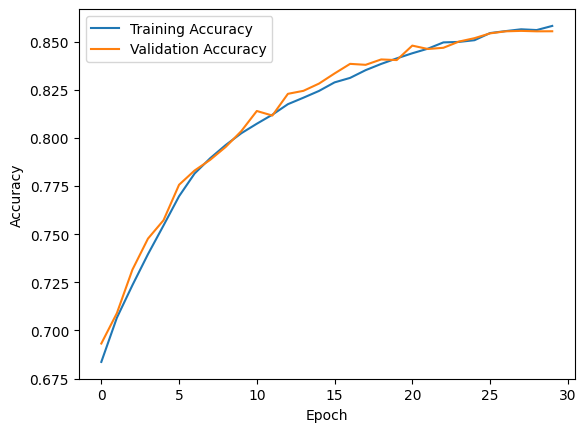

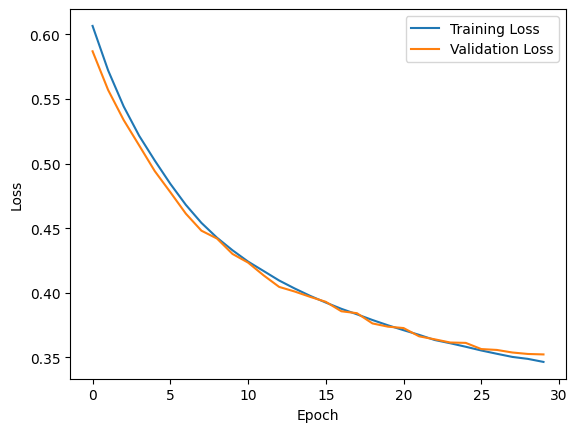

In [28]:
plot_acc_loss(history)

522/522 [==============================] - 2s 3ms/step


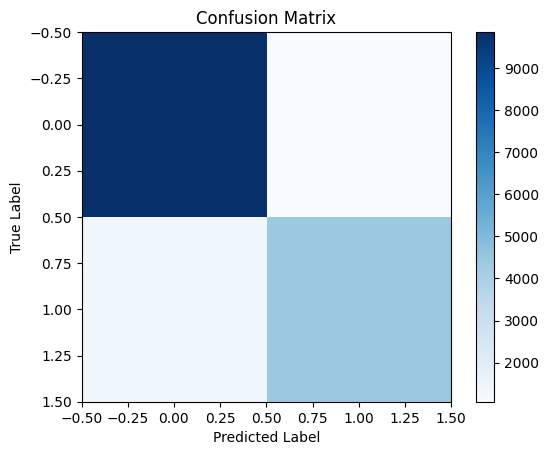

Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.90      0.89     10919
         1.0       0.80      0.76      0.78      5785

    accuracy                           0.85     16704
   macro avg       0.84      0.83      0.83     16704
weighted avg       0.85      0.85      0.85     16704



In [29]:
evaluate_model(model)

### SVM Implementation

In [17]:
from sklearn.svm import SVC

In [18]:
# Load data
data = load_data(phys_data_60)

167040
         eda     bvp   temp   x   y   z  emotion
0       0.00   -0.03  31.63 -13 -18  62        0
1       0.04    5.06  31.63 -15 -18  62        0
2       0.08   17.91  31.63 -14 -17  62        0
3       0.08   79.34  31.63 -16 -17  60        0
4       0.08  228.25  31.63   3 -12  63        0
...      ...     ...    ...  ..  ..  ..      ...
167995  0.33  -35.69  36.05 -53  23  16        1
167996  0.35  291.37  36.11 -66  23   1        1
167997  0.35  -99.97  36.11 -63  19  -8        1
167998  0.35  -48.63  36.11 -61  22 -10        1
167999  0.34   59.01  36.11 -61  20 -10        1

[167040 rows x 7 columns]


In [19]:
# Separate features (x) and labels (y)
x = data.drop('emotion', axis=1).values
y = data['emotion'].values

# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [20]:
print("Training Data: " + str(len(x_train)))
print("Test Data: " + str(len(x_test)))
print("Classes: " + str(np.unique(y)) )

Training Data: 133632
Test Data: 33408
Classes: [0 1]


In [21]:
# Model Parameters
c = 5.0
kernel = 'rbf'
gamma = 'auto'

In [22]:
# Create and train the SVM model
svm_model = SVC(kernel=kernel, gamma=gamma, C=c, random_state=42)
svm_model.fit(x_train, y_train)

SVC(C=5.0, gamma='auto', random_state=42)

In [23]:
# Prediction on test data
y_pred = svm_model.predict(x_test)

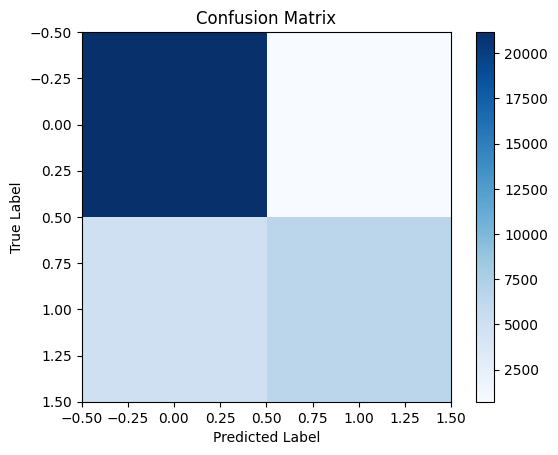

In [24]:
# Evaluate Model
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [25]:
# Classification report c=5
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.97      0.88     21893
           1       0.90      0.57      0.70     11515

    accuracy                           0.83     33408
   macro avg       0.85      0.77      0.79     33408
weighted avg       0.84      0.83      0.82     33408

